<a href="https://colab.research.google.com/github/ruveydakarakoyun/APTOS-2019/blob/main/aptos_2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Veri Yükleme ve Kütüphaneleri Yükleme

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU kullanılabilir mi?:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
GPU kullanılabilir mi?: False


In [ ]:
import torch

# 1. GPU Kontrolü ve Cihaz Ataması
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ Aktif Cihaz: {device}")

if device.type == "cuda":
    print(f"✅ GPU Model: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU aktif değil! Menüden 'Runtime -> Change runtime type -> T4 GPU' seçin.")


In [ ]:
# Google Cloud Kimlik Doğrulama
from google.colab import auth
auth.authenticate_user()

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from google.cloud import bigquery, storage

# Proje ve Bucket bilgilerin (Kendi Project ID'ni yaz)
PROJECT_ID = "datascience-project-id"  # GCP ekranındaki Project ID
BUCKET_NAME = "aptos2019-retina-images" # Cloud Storage bucket adın

print("✅ Bağlantı ve kütüphaneler hazır!")

✅ Bağlantı ve kütüphaneler hazır!


###BigQuery'den Tabloları Çekme

In [ ]:
from google.cloud import bigquery, storage

# ==============================================================================
# PROJE GENEL YAPILANDIRMASI (CONFIG)
# ==============================================================================
GCP_PROJECT_ID = "datascientis"
GCS_BUCKET_NAME = "aptos2019-retina-images"
BIGQUERY_DATASET = "APTOS_2019"

# Bucket içindeki klasör yolları (Prefix)
PATH_PREFIXES = {
    "train": "aptos_train_images/",
    "valid": "aptos_valid_images/",
    "test":  "aptos_test_images/"
}

# BigQuery tablo yolları
BQ_TABLES = {
    "train": f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_train",
    "valid": f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_valid",
    "test":  f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_test"
}

# ==============================================================================
# BİGQUERY'DEN VERİLERİ ÇEKME
# ==============================================================================
bq_client = bigquery.Client(project=GCP_PROJECT_ID)

# image_file kolonunu da sorguya ekledik
query_train = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['train']}`"
query_valid = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['valid']}`"
query_test  = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['test']}`"

df_train = bq_client.query(query_train).to_dataframe()
df_valid = bq_client.query(query_valid).to_dataframe()
df_test  = bq_client.query(query_test).to_dataframe()

print(f"📊 Train Veri Sayısı : {len(df_train)}")
print(f"📊 Valid Veri Sayısı : {len(df_valid)}")
print(f"📊 Test Veri Sayısı  : {len(df_test)}")

In [ ]:
import io
import torch
from torch.utils.data import Dataset
from PIL import Image
from google.cloud import storage

class APTOSDataset(Dataset):
    def __init__(self, df, bucket_name, project_id, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        # 🔑 KRİTİK NOKTA: GCS istemcisi SADECE 1 KERE burada oluşturulur.
        # Her resim için baştan istemci kurulmaz!
        self.client = storage.Client(project=project_id)
        self.bucket = self.client.bucket(bucket_name)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Görsel yolunu al (id_code veya image_path)
        img_name = row['id_code'] if 'id_code' in row else row['image_id']

        # Eğer uzantı yoksa .png ekle
        if not img_name.endswith('.png') and not img_name.endswith('.jpg'):
            img_name = f"{img_name}.png"

        # Blob üzerinden doğrudan byte olarak okuma (en hızlı yöntem)
        blob = self.bucket.blob(f"train_images/{img_name}")
        image_bytes = blob.download_as_bytes()

        # PIL Image dönüştürme
        image = Image.open(io.BytesIO(image_bytes)).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Etiket (diagnosis)
        label = torch.tensor(row['diagnosis'], dtype=torch.long)

        return image, label

###Dataframe'leri ve Transform'ları Ayırma

In [ ]:
# Transform tanımları
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset ve DataLoader nesneleri
train_dataset = APTOSDataset(df_train, BUCKET_NAME, PROJECT_ID, transform=train_transform)
valid_dataset = APTOSDataset(df_valid, BUCKET_NAME, PROJECT_ID, transform=eval_transform)
test_dataset  = APTOSDataset(df_test,  BUCKET_NAME, PROJECT_ID, transform=eval_transform)

# num_workers=0 ve pin_memory=True ekleyerek GCS kilitlenmesini engelliyoruz
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print("✅ DataLoader bağlantıları yenilendi!")

#EDA

###Sınıf dağılımı (Evre 0 - Evre 4 kaçar adet?) grafikleri ve Sınıf dengesizliği oranları


📊 Train Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,1434,48.94
1,1,Mild,300,10.24
2,2,Moderate,808,27.58
3,3,Severe,154,5.26
4,4,Proliferative DR,234,7.99


En fazla görüntü: Evre 0 → 1434
En az görüntü: Evre 3 → 154
Sınıf dengesizlik oranı (Max / Min): 9.31


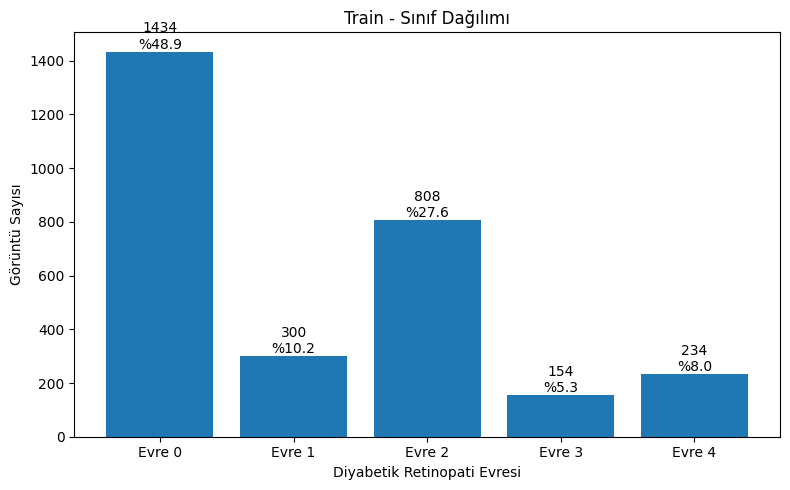


📊 Validation Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,172,46.99
1,1,Mild,40,10.93
2,2,Moderate,104,28.42
3,3,Severe,22,6.01
4,4,Proliferative DR,28,7.65


En fazla görüntü: Evre 0 → 172
En az görüntü: Evre 3 → 22
Sınıf dengesizlik oranı (Max / Min): 7.82


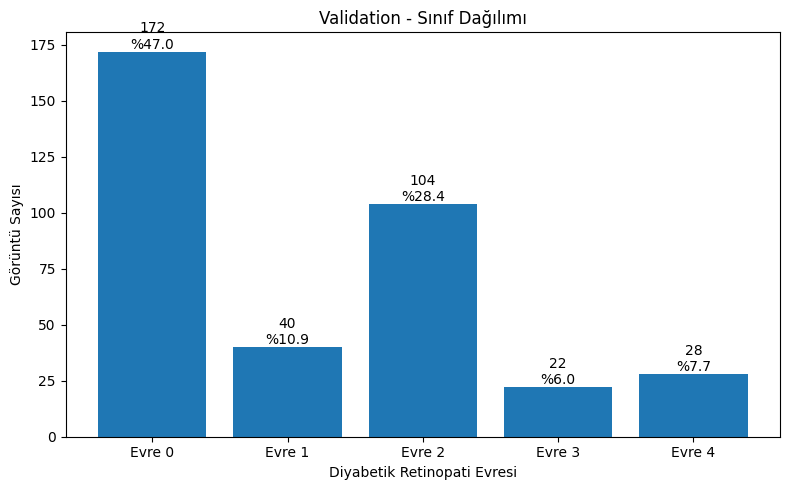


📊 Test Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,199,54.37
1,1,Mild,30,8.2
2,2,Moderate,87,23.77
3,3,Severe,17,4.64
4,4,Proliferative DR,33,9.02


En fazla görüntü: Evre 0 → 199
En az görüntü: Evre 3 → 17
Sınıf dengesizlik oranı (Max / Min): 11.71


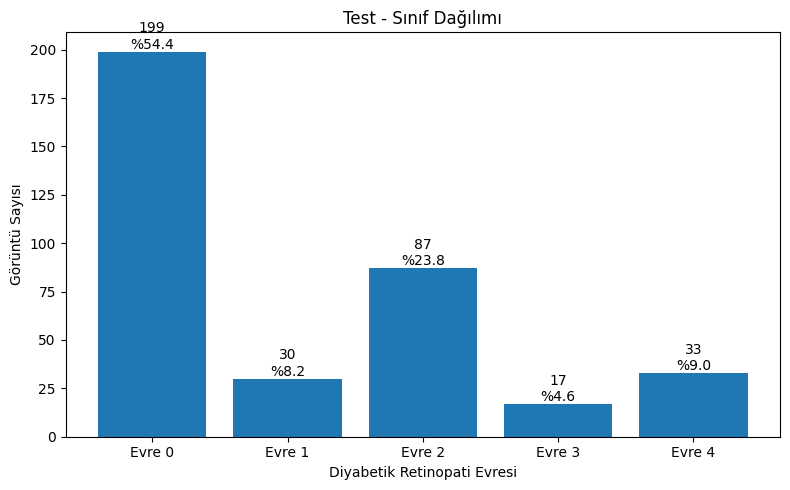

In [ ]:
# Sınıf dağılımı
# Sınıf isimleri
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

datasets = {
    "Train": df_train,
    "Validation": df_valid,
    "Test": df_test
}

for dataset_name, df in datasets.items():

    # Her sınıftaki görüntü sayısı
    counts = (
        df["diagnosis"]
        .value_counts()
        .reindex(range(5), fill_value=0)
        .sort_index()
    )

    # Yüzdelik dağılım
    percentages = (counts / counts.sum()) * 100

    # Sonuç tablosu
    distribution_table = pd.DataFrame({
        "Evre": counts.index,
        "Sınıf": [class_names[i] for i in counts.index],
        "Görüntü Sayısı": counts.values,
        "Yüzde (%)": percentages.round(2).values
    })

    print(f"\n📊 {dataset_name} Sınıf Dağılımı")
    display(distribution_table)

    # Sınıf dengesizliği
    non_zero_counts = counts[counts > 0]

    max_count = non_zero_counts.max()
    min_count = non_zero_counts.min()

    imbalance_ratio = max_count / min_count

    print(f"En fazla görüntü: Evre {non_zero_counts.idxmax()} → {max_count}")
    print(f"En az görüntü: Evre {non_zero_counts.idxmin()} → {min_count}")
    print(f"Sınıf dengesizlik oranı (Max / Min): {imbalance_ratio:.2f}")

    # Grafik
    plt.figure(figsize=(8, 5))

    bars = plt.bar(
        [f"Evre {i}" for i in counts.index],
        counts.values
    )

    plt.title(f"{dataset_name} - Sınıf Dağılımı")
    plt.xlabel("Diyabetik Retinopati Evresi")
    plt.ylabel("Görüntü Sayısı")

    for bar, count, percentage in zip(
        bars, counts.values, percentages.values
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count}\n%{percentage:.1f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

 ### Ham retina resimlerinin piksel boyutları, çözünürlükleri ve renk kanalları (RGB/Grayscale) kontrol edilir.

In [ ]:
from google.cloud import storage, bigquery # bigquery eklendi
import io
from tqdm.auto import tqdm
import pandas as pd
from PIL import Image # Image eklendi

GCP_PROJECT_ID = "datascientis"
GCS_BUCKET_NAME = "aptos2019-retina-images"
BIGQUERY_DATASET = "APTOS_2019"
PROJECT_ID = "datascience-project-id"  # GCP ekranındaki Project ID
BUCKET_NAME = "aptos2019-retina-images" # Cloud Storage bucket adın

# Cloud Storage bağlantısı
storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(BUCKET_NAME)

# GCS klasörleri
folder_map = {
    "Train": "aptos_train_images",
    "Validation": "aptos_valid_images",
    "Test": "aptos_test_images"
}

# ==============================================================================
# BİGQUERY'DEN VERİLERİ ÇEKME (df_train, df_valid, df_test için) - Bu bölge eklendi
# ==============================================================================
bq_client = bigquery.Client(project=GCP_PROJECT_ID)

# BigQuery tablo yolları
BQ_TABLES = {
    "train": f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_train",
    "valid": f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_valid",
    "test":  f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_test"
}

# image_file kolonunu da sorguya ekledik
query_train = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['train']}`"
query_valid = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['valid']}`"
query_test  = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['test']}`"

df_train = bq_client.query(query_train).to_dataframe()
df_valid = bq_client.query(query_valid).to_dataframe()
df_test  = bq_client.query(query_test).to_dataframe()

# Train, Validation ve Test verilerini birleştir
all_df = pd.concat([
    df_train.assign(split="Train"),
    df_valid.assign(split="Validation"),
    df_test.assign(split="Test")
], ignore_index=True)

image_properties = []
error_count = 0

for _, row in tqdm(
    all_df.iterrows(),
    total=len(all_df),
    desc="Görüntüler inceleniyor"
):

    # Görüntü dosya adı
    image_name = f"{row['id_code']}.png"

    # Görüntünün bulunduğu GCS klasörü
    folder = folder_map[row["split"]]

    # GCS'deki tam dosya yolu
    blob_path = f"{folder}/{image_name}"

    try:
        # Görüntüyü GCS'den oku
        blob = bucket.blob(blob_path)
        image_bytes = blob.download_as_bytes()

        # PIL ile ham görüntüyü aç
        img = Image.open(io.BytesIO(image_bytes))

        # Görüntü özellikleri
        width, height = img.size
        color_mode = img.mode
        channels = len(img.getbands())

        image_properties.append({
            "id_code": row["id_code"],
            "split": row["split"],
            "width": width,
            "height": height,
            "resolution": f"{width}x{height}",
            "color_mode": color_mode,
            "channels": channels
        })

    except Exception as e:

        error_count += 1

        image_properties.append({
            "id_code": row["id_code"],
            "split": row["split"],
            "width": None,
            "height": None,
            "resolution": None,
            "color_mode": None,
            "channels": None
        })


# Sonuçları DataFrame'e dönüştür
image_properties_df = pd.DataFrame(image_properties)

print("\n✅ Ham görüntü özellikleri incelendi.")
print(f"Toplam görüntü sayısı: {len(image_properties_df)}")
print(f"Başarıyla okunan görüntü: {len(image_properties_df) - error_count}")
print(f"Okunamayan görüntü: {error_count}")

display(image_properties_df.head())

Görüntüler inceleniyor:   0%|          | 0/3662 [00:00<?, ?it/s]

In [ ]:
# Ham görüntü analizi özeti

print("📐 GÖRÜNTÜ BOYUTLARI")
display(
    image_properties_df[["width", "height"]].describe()
)

print("\n🖼️ TOPLAM FARKLI ÇÖZÜNÜRLÜK SAYISI")
print(image_properties_df["resolution"].nunique())

print("\n🖼️ EN SIK GÖRÜLEN 10 ÇÖZÜNÜRLÜK")
display(
    image_properties_df["resolution"]
    .value_counts()
    .head(10)
)

print("\n🎨 RENK MODLARI")
display(
    image_properties_df["color_mode"].value_counts()
)

print("\n📺 KANAL SAYILARI")
display(
    image_properties_df["channels"].value_counts()
)

📐 GÖRÜNTÜ BOYUTLARI


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c86d0207e20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1673, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

NameError: name 'image_properties_df' is not defined

Ham retina görüntülerinin çözünürlüklerinin sabit olmadığı ve veri setinde 17 farklı çözünürlük bulunduğu görülmüştür. Görüntü boyutları 474×358 ile 4288×2848 arasında değişmektedir. Tüm 3662 görüntünün RGB formatında ve 3 kanallı olduğu doğrulanmıştır. Bu nedenle modelleme öncesinde görüntülerin ortak bir boyuta yeniden ölçeklendirilmesi gerekmektedir.

###Veri Temizleme ve Kalite Kontrol Betiği

Bozuk, açılmayan veya aşırı karanlık görseller için hızlı bir veri temizleme kontrol betiği

In [ ]:
import io
import pandas as pd
from PIL import Image, ImageStat
from google.cloud import storage
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def verify_single_image(row, bucket_name, project_id, folder_prefix, brightness_threshold):
    storage_client = storage.Client(project=project_id)
    bucket = storage_client.bucket(bucket_name)

    img_file = row['image_file'] if 'image_file' in row and pd.notnull(row['image_file']) else f"{row['id_code']}.png"
    full_blob_path = f"{folder_prefix}{img_file}"

    try:
        blob = bucket.blob(full_blob_path)
        image_bytes = blob.download_as_bytes()
        img = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        stat = ImageStat.Stat(img.convert("L"))
        mean_brightness = stat.mean[0]

        if mean_brightness < brightness_threshold:
            return ('dark', row['id_code'], full_blob_path, mean_brightness)
        else:
            return ('valid', row.name, None, None)

    except Exception as e:
        return ('corrupted', row['id_code'], full_blob_path, str(e))

def check_dataset_quality_fast(df, bucket_name, project_id, folder_prefix="", brightness_threshold=12.0, max_workers=20):
    print(f"🚀 '{folder_prefix}' klasörü {max_workers} eşzamanlı kanaldan hızlıca kontrol ediliyor...\n")

    corrupted_images = []
    too_dark_images = []
    valid_indices = []

    # Satırları listeye çevirip paralel iş parçacıklarına bölüyoruz
    rows = [row for _, row in df.iterrows()]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(verify_single_image, row, bucket_name, project_id, folder_prefix, brightness_threshold)
            for row in rows
        ]

        for future in tqdm(futures, total=len(futures)):
            status, arg1, arg2, arg3 = future.result()
            if status == 'valid':
                valid_indices.append(arg1)
            elif status == 'dark':
                too_dark_images.append({'id_code': arg1, 'path': arg2, 'brightness': arg3})
            elif status == 'corrupted':
                corrupted_images.append({'id_code': arg1, 'path': arg2, 'error': arg3})

    print("\n" + "="*40)
    print("📋 HIZLANDIRILMIŞ KONTROL SONUÇLARI RAPORU")
    print("="*40)
    print(f"✅ Sağlam ve Geçerli Görsel Sayısı : {len(valid_indices)}")
    print(f"❌ Bozuk / Bulunamayan Görsel Sayısı: {len(corrupted_images)}")
    print(f"⚠️  Aşırı Karanlık Görsel Sayısı  : {len(too_dark_images)}")

    return valid_indices, corrupted_images, too_dark_images

# --- HIZLI TESTİ BAŞLAT ---
valid_idx, corrupted_list, dark_list = check_dataset_quality_fast(
    df=df_train,
    bucket_name=GCS_BUCKET_NAME,
    project_id=GCP_PROJECT_ID,
    folder_prefix=PATH_PREFIXES['train'],
    max_workers=20  # Aynı anda 20 resim indirir
)

🚀 'aptos_train_images/' klasörü 20 eşzamanlı kanaldan hızlıca kontrol ediliyor...



  9%|▉         | 263/2930 [00:31<05:19,  8.36it/s]


KeyboardInterrupt: 

###Göz etrafındaki siyah boşlukları otomatik kesen Auto-Crop uygulama.

In [ ]:
def auto_crop(image, threshold=10, padding=5):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold

    if not np.any(mask):
        return image

    y_coords, x_coords = np.where(mask)

    x_min = max(0, x_coords.min() - padding)
    y_min = max(0, y_coords.min() - padding)
    x_max = min(image.shape[1], x_coords.max() + padding + 1)
    y_max = min(image.shape[0], y_coords.max() + padding + 1)

    return image[y_min:y_max, x_min:x_max]

In [ ]:
class APTOSDataset(Dataset):
    def __init__(self, df, bucket_name, project_id, folder_prefix="", transform=None):
        self.df = df
        self.folder_prefix = folder_prefix
        self.transform = transform
        storage_client = storage.Client(project=project_id)
        self.bucket = storage_client.bucket(bucket_name)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = row['image_file'] if 'image_file' in row and pd.notnull(row['image_file']) else f"{row['id_code']}.png"
        label = int(row['diagnosis']) if 'diagnosis' in row and pd.notnull(row['diagnosis']) else -1

        full_blob_path = f"{self.folder_prefix}{img_file}"

        blob = self.bucket.blob(full_blob_path)
        image_bytes = blob.download_as_bytes()

        img_pil = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        img_np = np.array(img_pil)

        # 1. Adımdaki fonksiyonu burada kullanıyoruz:
        img_cropped = auto_crop(img_np, threshold=10, padding=5)
        img_final = Image.fromarray(img_cropped)

        if self.transform:
            img_tensor = self.transform(img_final)
        else:
            img_tensor = transforms.ToTensor()(img_final)

        return img_tensor, torch.tensor(label, dtype=torch.long)

### Auto-Crop'u tek bir görüntüde test et

In [ ]:
# Auto-Crop'u tek bir görüntüde test et

test_id = str(df_train.iloc[0]["id_code"])
blob_path = f"aptos_train_images/{test_id}.png"

blob = bucket.blob(blob_path)
image_bytes = blob.download_as_bytes()

# PIL ile oku
img_pil = Image.open(io.BytesIO(image_bytes)).convert("RGB")

# NumPy array'e çevir
original_image = np.array(img_pil)

# Auto-Crop uygula
cropped_image = auto_crop(original_image)

print("Orijinal boyut:", original_image.shape)
print("Crop sonrası boyut:", cropped_image.shape)

Orijinal boyut: (614, 819, 3)
Crop sonrası boyut: (614, 770, 3)


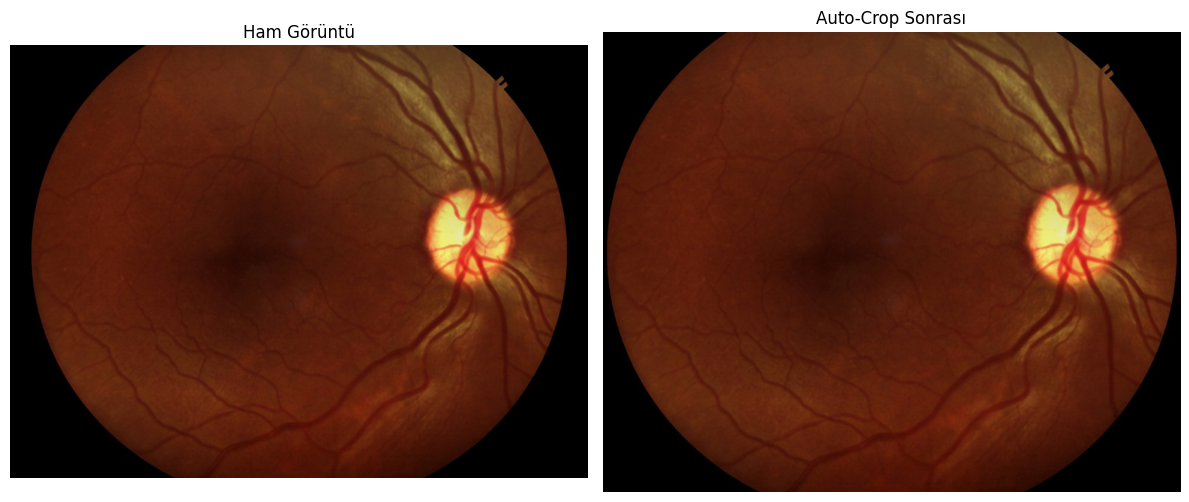

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Ham Görüntü")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_image)
plt.title("Auto-Crop Sonrası")
plt.axis("off")

plt.tight_layout()
plt.show()

###CLAHE :Kılcal damarları netleştirmek için CLAHE (Kontrast Artırma) algoritması kodlanır ve görsellere uygulanır.

In [ ]:
# CLAHE
# Retina görüntüsünde lokal kontrastı artırır

def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):

    # RGB -> LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # L, A, B kanallarını ayır
    l, a, b = cv2.split(lab)

    # CLAHE oluştur
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    # Sadece parlaklık (L) kanalına CLAHE uygula
    l_clahe = clahe.apply(l)

    # Kanalları tekrar birleştir
    lab_clahe = cv2.merge((l_clahe, a, b))

    # LAB -> RGB
    enhanced_image = cv2.cvtColor(
        lab_clahe,
        cv2.COLOR_LAB2RGB
    )

    return enhanced_image

In [ ]:
clahe_image = apply_clahe(cropped_image)

print("Auto-Crop görüntü boyutu:", cropped_image.shape)
print("CLAHE görüntü boyutu:", clahe_image.shape)

Auto-Crop görüntü boyutu: (614, 770, 3)
CLAHE görüntü boyutu: (614, 770, 3)


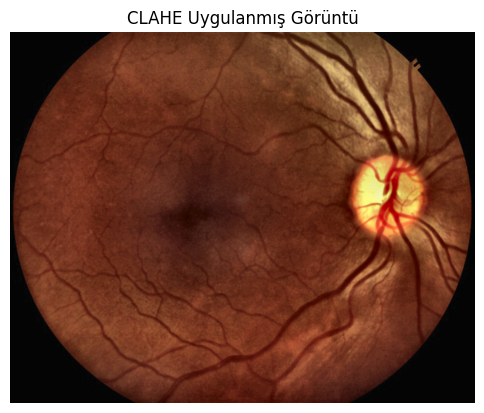

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(clahe_image)
plt.title("CLAHE Uygulanmış Görüntü")
plt.axis("off")

plt.show()

In [ ]:
# CLAHE öncesi ve sonrası karşılaştırma fonksiyonu

def compare_clahe(before_image, after_image):

    plt.figure(figsize=(12, 5))

    # CLAHE öncesi
    plt.subplot(1, 2, 1)
    plt.imshow(before_image)
    plt.title("CLAHE Öncesi")
    plt.axis("off")

    # CLAHE sonrası
    plt.subplot(1, 2, 2)
    plt.imshow(after_image)
    plt.title("CLAHE Sonrası")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
compare_clahe(cropped_image, clahe_image)

# PyTorch Dataset & Data Augmentation

### Albumentations kütüphanesi kullanılarak rastgele döndürme (rotation), yatay/dikey çevirme (flip) gibi Data Augmentation süreçleri (Eğitim (train) veri setinde çeşitliliği artırmak için güçlü dönüşümler eklerken, doğrulama (valid) veri setinde resimlerin orijinal yapısını koruyup sadece boyutlandırma ve normalize etme işlemleri uyguluyoruz)

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Eğitim verisi için Augmentation
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Validation ve Test verisi için (Sadece Resize + Normalize)
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


** Albumentations kütüphanesi standart PIL görselleri yerine NumPy dizileri (np.ndarray) ile çalışır. Bu yüzden __getitem__ içinde kırpma işleminden sonra resmi NumPy formatında tutup transform(image=img_cropped) şeklinde çağırmamız gerekir

In [ ]:
import io
import torch
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from google.cloud import storage

class APTOSDataset(Dataset):
    def __init__(self, df, bucket_name, project_id, folder_prefix="", transform=None):
        self.df = df.reset_index(drop=True)
        self.folder_prefix = folder_prefix
        self.transform = transform

        # GCP Bucket Bağlantısı
        storage_client = storage.Client(project=project_id)
        self.bucket = storage_client.bucket(bucket_name)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = row['image_file'] if 'image_file' in row and pd.notnull(row['image_file']) else f"{row['id_code']}.png"
        label = int(row['diagnosis']) if 'diagnosis' in row and pd.notnull(row['diagnosis']) else -1

        # 1. GCS'den resmi okuma
        full_blob_path = f"{self.folder_prefix}{img_file}"
        blob = self.bucket.blob(full_blob_path)
        image_bytes = blob.download_as_bytes()

        # 2. Resmi açma ve auto_crop uygulama
        img_pil = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        img_np = np.array(img_pil)
        img_cropped = auto_crop(img_np, threshold=10, padding=5)

        # 3. Albumentations Augmentation Uygulama
        if self.transform:
            augmented = self.transform(image=img_cropped)
            img_tensor = augmented['image']
        else:
            # Dönüşüm yoksa varsayılan PyTorch tensor formatına çevirme
            img_tensor = torch.tensor(img_cropped).permute(2, 0, 1).float() / 255.0

        return img_tensor, torch.tensor(label, dtype=torch.long)

###PyTorch Dataset ve DataLoader sınıfları kodlanır.

####DataDataLoader'ları Hazırlama

In [ ]:
from torch.utils.data import DataLoader

# Dataset nesnelerini oluşturma
train_dataset = APTOSDataset(
    df=df_train,
    bucket_name=BUCKET_NAME,
    project_id=PROJECT_ID,
    folder_prefix="train_images/",
    transform=train_transform
)

val_dataset = APTOSDataset(
    df=df_valid,
    bucket_name=BUCKET_NAME,
    project_id=PROJECT_ID,
    folder_prefix="train_images/",
    transform=val_transform
)

# DataLoader yükleyicileri
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"✅ Eğitim seti boyutu: {len(train_dataset)} | Batch sayısı: {len(train_loader)}")
print(f"✅ Doğrulama seti boyutu: {len(val_dataset)} | Batch sayısı: {len(val_loader)}")

✅ Eğitim seti boyutu: 2930 | Batch sayısı: 92
✅ Doğrulama seti boyutu: 366 | Batch sayısı: 12


###Eğitim, doğrulama (validation) ve test veri yükleyicilerinin sorunsuz veri beslediği test etme

In [ ]:
import torch
from torch.utils.data import DataLoader

# 1. Dataset Nesneleri (Klasör isimleri Bucket ile birebir eşlendi)
train_dataset = APTOSDataset(
    df=df_train,
    bucket_name=BUCKET_NAME,
    project_id=PROJECT_ID,
    folder_prefix="aptos_train_images/",  # Eğer train görselleri bu klasördeyse
    transform=train_transform
)

val_dataset = APTOSDataset(
    df=df_valid,
    bucket_name=BUCKET_NAME,
    project_id=PROJECT_ID,
    folder_prefix=PATH_PREFIXES['valid'], # Düzeltme: Doğru klasör yolu
    transform=val_transform
)

test_dataset = APTOSDataset(
    df=df_test,
    bucket_name=BUCKET_NAME,
    project_id=PROJECT_ID,
    folder_prefix="aptos_test_images/",   # Çıktınızda gördüğümüz klasör adı
    transform=val_transform
)

# 2. DataLoader'lar (Batch size: 32)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Try-except bloğunu kaldırarak hatanın detaylı traceback'ini alıyoruz
# 1. Train Loader'dan ilk batch'i çekme
images, labels = next(iter(train_loader))

print("✅ DataLoader Testi Başarılı!")
print(f"• Gelen Resim Batch Boyutu (Shape) : {images.shape}")
print(f"• Gelen Etiket Batch Boyutu (Shape): {labels.shape}")
print(f"• Veri Tipi (Dtype)                 : {images.dtype}")
print(f"• Etiket Örnekleri (İlk 5)          : {labels[:5].tolist()}")

# 2. Görselleştirme Testi
# Tensor [C, H, W] -> NumPy [H, W, C]
sample_img = images[0].permute(1, 2, 0).cpu().numpy()

# Denormalizasyon
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
sample_img = std * sample_img + mean
sample_img = np.clip(sample_img, 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(f"Örnek Etiket (Diagnosis): {labels[0].item()}")
plt.axis("off")
plt.show()

NameError: Caught NameError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_276/4122939359.py", line 35, in __getitem__
    img_cropped = auto_crop(img_np, threshold=10, padding=5)
                  ^^^^^^^^^
NameError: name 'auto_crop' is not defined


In [ ]:
# DataLoader Test Hücresi
import matplotlib.pyplot as plt

try:
    # 1. Train Loader'dan ilk batch'i çekmeyi deneyelim
    images, labels = next(iter(train_loader))

    print("✅ DataLoader Testi Başarılı!")
    print(f"• Gelen Resim Batch Boyutu (Shape) : {images.shape}")  # [32, 3, 224, 224] olmalı
    print(f"• Gelen Etiket Batch Boyutu (Shape): {labels.shape}")  # [32] olmalı
    print(f"• Veri Tipi (Dtype)                 : {images.dtype}")
    print(f"• Etiket Örnekleri (İlk 5)          : {labels[:5].tolist()}")

    # 2. Görselleştirme Testi (İlk resmin ekrana basılması)
    # Tensor formatını [C, H, W] -> NumPy formatına [H, W, C] çevirme
    sample_img = images[0].permute(1, 2, 0).cpu().numpy()

    # Normalizasyonu geri alıp (Un-normalize) görselleştirme
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    sample_img = std * sample_img + mean
    sample_img = np.clip(sample_img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(sample_img)
    plt.title(f"Örnek Etiket (Diagnosis): {labels[0].item()}")
    plt.axis("off")
    plt.show()

except Exception as e:
    print("❌ DataBorusu Testinde Hata Oluştu:")
    print(e)

❌ DataBorusu Testinde Hata Oluştu:
Caught NameError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_276/4122939359.py", line 35, in __getitem__
    img_cropped = auto_crop(img_np, threshold=10, padding=5)
                  ^^^^^^^^^
NameError: name 'auto_crop' is not defined



In [ ]:
# Veri Borusu Doğrulama Testi
try:
    images, labels = next(iter(train_loader))
    print(f"✅ HARİKA! Train Loader başarıyla bağlandı.")
    print(f"• Batch Resim Boyutu  : {images.shape}")  # [32, 3, 224, 224]
    print(f"• Batch Etiket Boyutu : {labels.shape}")  # [32]
except Exception as e:
    print("❌ Hata devam ediyor:")
    print(e)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c86d0207e20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Exception ignored in: self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7c86d0207e20>

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
         if w.is_alive(): 
  ^  ^^ ^ ^ ^ ^^^^^^^^^^
^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^^  
    File "/usr/lib/py

❌ Hata devam ediyor:
Caught NameError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_276/4122939359.py", line 35, in __getitem__
    img_cropped = auto_crop(img_np, threshold=10, padding=5)
                  ^^^^^^^^^
NameError: name 'auto_crop' is not defined



#Model Mimarisi & Kayıp Fonksiyonu (Loss)

##Baseline (temel) basit bir custom CNN veya hafif model mimarisi hazırlama

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(BaselineCNN, self).__init__()

        # 1. Evrişim Katmanları (Feature Extractor)
        # Giriş: [Batch, 3, 224, 224]
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Haritayı yarıya indirir

        # 224 -> Pool1 -> 112 -> Pool2 -> 56 -> Pool3 -> 28
        # Düzleştirilmiş vektör boyutu: 64 kanal * 28 * 28 piksel = 50,176

        # 2. Tam Bağlantılı Katmanlar (Classifier)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Katman 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Katman 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Katman 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Tensor'ü tek boyuta düzleştirme (Flatten)
        x = x.view(x.size(0), -1)

        # Sınıflandırma
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Modeli örnekleme ve GPU/CPU cihazına gönderme
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = BaselineCNN(num_classes=5).to(device)

print(f"✅ Baseline Custom CNN hazırlandı ve {device} cihazına yüklendi!")

✅ Baseline Custom CNN hazırlandı ve cpu cihazına yüklendi!


##Baseline Modeli Test Etme (Dry Run)
Modelin beklenen girdi boyutlarını alıp sorunsuz çıktı verip vermediğini test etmek için train_loader'dan tek bir batch geçirerek doğrulayalım:

In [ ]:
# Modeli sahte/test verisiyle kontrol etme
images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = baseline_model(images)

print(f"• Girdi Batch Boyutu : {images.shape}")   # [32, 3, 224, 224]
print(f"• Çıktı Batch Boyutu : {outputs.shape}")  # [32, 5] (32 resim için 5 sınıf skoru)
print("✅ Baseline model sorunsuz ileri besleme (forward pass) yapıyor!")

NameError: Caught NameError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_276/4122939359.py", line 35, in __getitem__
    img_cropped = auto_crop(img_np, threshold=10, padding=5)
                  ^^^^^^^^^
NameError: name 'auto_crop' is not defined


###Eğitim ve Doğrulama Fonksiyonları (train_one_epoch & validate)
Bu fonksiyonlar her epoch'ta veriyi modele besleyecek, kayıp (loss) değerini hesaplayıp ağırlıkları güncelleyecek ve doğrulama başarısını ölçece

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc="Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc

###Baseline Modeli Eğitme (3 Epoch Test Eğitimi)
Uçtan uca sistemin öğrendiğini doğrulamak için Baseline Custom CNN modelimizi 3 epoch boyunca eğitelim:

In [ ]:
# 1. Kayıp Fonksiyonu ve Optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=1e-3)

# 2. Deneme Eğitimi
epochs = 3
print(f"🚀 Baseline Custom CNN Eğitimi Başlıyor ({device} üzerinde)...")

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(baseline_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(baseline_model, val_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} - Train Acc: %{train_acc*100:.2f} | "
          f"Val Loss: {val_loss:.4f} - Val Acc: %{val_acc*100:.2f}")

NameError: name 'baseline_model' is not defined

##Torchvision veya timm üzerinden EfficientNet-B0 ve ResNet50 modelleri çağrılır, son çıktı katmanları 5 sınıfa uyarlanır. Sınıf dengesizliği için Weighted Cross-Entropy ağırlıkları hesaplanır.

In [ ]:
# ============================================================
# EfficientNet-B0 + ResNet50
# 5 sınıfa uyarlama + Weighted Cross-Entropy
# ============================================================

import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
    resnet50,
    ResNet50_Weights
)

# Cihaz
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

NUM_CLASSES = 5

print("Kullanılan cihaz:", device)


# ============================================================
# 1. SINIF AĞIRLIKLARINI HESAPLA
# ============================================================

# Sadece TRAIN seti kullanılmalı
class_counts = (
    df_train["diagnosis"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

print("\nTrain sınıf dağılımı:")
print(class_counts)


# Weighted Cross-Entropy için ağırlık:
# total_samples / (num_classes * class_count)

total_samples = class_counts.sum()

class_weights = (
    total_samples /
    (NUM_CLASSES * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nSınıf ağırlıkları:")
for i, weight in enumerate(class_weights):
    print(f"Evre {i}: {weight.item():.4f}")


# ============================================================
# 2. WEIGHTED CROSS-ENTROPY LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("\n✅ Weighted Cross-Entropy Loss hazır.")


# ============================================================
# 3. EFFICIENTNET-B0
# ============================================================

efficientnet_model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

# EfficientNet-B0'nun son Linear katmanının giriş boyutu
efficientnet_in_features = (
    efficientnet_model.classifier[1].in_features
)

# Son katmanı 5 sınıfa çevir
efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_in_features,
    NUM_CLASSES
)

efficientnet_model = efficientnet_model.to(device)

print("✅ EfficientNet-B0 hazır: çıktı sınıfı = 5")


# ============================================================
# 4. RESNET50
# ============================================================

resnet50_model = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# ResNet50'nin son FC katmanının giriş boyutu
resnet_in_features = resnet50_model.fc.in_features

# Son katmanı 5 sınıfa çevir
resnet50_model.fc = nn.Linear(
    resnet_in_features,
    NUM_CLASSES
)

resnet50_model = resnet50_model.to(device)

print("✅ ResNet50 hazır: çıktı sınıfı = 5")

Kullanılan cihaz: cpu


NameError: name 'df_train' is not defined

In [ ]:
# Model çıktı boyutlarını test et

dummy_input = torch.randn(
    2, 3, 224, 224
).to(device)

efficientnet_model.eval()
resnet50_model.eval()

with torch.no_grad():

    eff_output = efficientnet_model(dummy_input)
    res_output = resnet50_model(dummy_input)

print(
    "EfficientNet-B0 çıktı:",
    eff_output.shape
)

print(
    "ResNet50 çıktı:",
    res_output.shape

###EfficientNet-B0, ResNet50 ve Weighted Cross-Entropy
Bu aşamada transfer learning yaklaşımı kullanılarak torchvision üzerinden önceden eğitilmiş EfficientNet-B0 ve ResNet50 modelleri projeye dahil edilmiştir. Her iki modelin son sınıflandırma katmanı, diyabetik retinopati veri setindeki 5 sınıfı (Evre 0–4) tahmin edecek şekilde yeniden düzenlenmiştir.

Eğitim veri setinde belirgin sınıf dengesizliği bulunduğu için yalnızca eğitim verisindeki sınıf frekansları kullanılarak sınıf ağırlıkları hesaplanmıştır. Bu ağırlıklar Weighted Cross-Entropy Loss fonksiyonuna aktarılmış ve az örneğe sahip sınıflardaki hataların eğitim sırasında daha fazla dikkate alınması amaçlanmıştır.



##Model değerlendirme metrikleri için fonksiyonlar yazılır: Accuracy, Precision, Recall ve QWK (Quadratic Weighted Kappa)

In [ ]:
# ============================================================
# MODEL DEĞERLENDİRME METRİKLERİ
# Accuracy, Precision, Recall ve QWK
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    cohen_kappa_score
)


def calculate_metrics(y_true, y_pred):

    # Accuracy
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    # Precision
    # Sınıf dengesizliği nedeniyle macro average kullanıyoruz
    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    # Recall
    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    # Quadratic Weighted Kappa
    qwk = cohen_kappa_score(
        y_true,
        y_pred,
        weights="quadratic"
    )

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "QWK": qwk
    }

    return metrics

In [ ]:
# Metrik fonksiyonunu hızlı test et

y_true_test = [0, 1, 2, 3, 4, 2, 0, 1]
y_pred_test = [0, 1, 2, 2, 4, 2, 0, 0]

test_metrics = calculate_metrics(
    y_true_test,
    y_pred_test
)

print("✅ Metrik fonksiyonları çalışıyor.\n")

for metric_name, value in test_metrics.items():
    print(
        f"{metric_name}: {value:.4f}"
    )

### Model Değerlendirme Metrikleri

Model performansını yalnızca doğruluk oranı üzerinden değerlendirmek yerine, sınıf dengesizliğini ve diyabetik retinopati evrelerinin sıralı yapısını dikkate alan bir değerlendirme altyapısı hazırlanmıştır.

Bu kapsamda **Accuracy**, **Macro Precision**, **Macro Recall** ve **Quadratic Weighted Kappa (QWK)** metriklerini hesaplayan bir fonksiyon oluşturulmuştur.

`Macro Precision` ve `Macro Recall`, her sınıfa eşit önem vererek özellikle az örneğe sahip sınıfların performansının da değerlendirmeye dahil edilmesini sağlar. `QWK` metriği ise sınıfların 0'dan 4'e sıralı yapısını dikkate alarak, tahmin edilen sınıf ile gerçek sınıf arasındaki hata büyüklüğünü değerlendirir.

Bu metrikler daha sonraki aşamalarda EfficientNet-B0, ResNet50 ve diğer modellerin performanslarını karşılaştırmak için kullanılacaktır.

In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

CHECKPOINT_DIR = "/content/drive/MyDrive/APTOS2019/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("✅ Model kayıt klasörü hazır:")
print(CHECKPOINT_DIR)

In [ ]:
import torch
import matplotlib.pyplot as plt

from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from IPython.display import clear_output


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True
):

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    # --------------------------------------------------------
    # Learning Rate Scheduler
    # Validation loss gelişmezse learning rate düşürülür
    # --------------------------------------------------------
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    # --------------------------------------------------------
    # Model kayıt yolları
    # --------------------------------------------------------
    best_model_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_best_model.pth"
    )

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_last_checkpoint.pth"
    )

    # --------------------------------------------------------
    # Başlangıç değerleri
    # --------------------------------------------------------
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    early_stop_counter = 0
    start_epoch = 0

    # --------------------------------------------------------
    # Önceden yarım kalmış eğitim varsa devam et
    # --------------------------------------------------------
    if resume and os.path.exists(checkpoint_path):

        print("♻️ Önceki checkpoint bulundu.")

        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        start_epoch = checkpoint["epoch"] + 1

        best_val_loss = checkpoint["best_val_loss"]

        train_losses = checkpoint.get(
            "train_losses",
            []
        )

        val_losses = checkpoint.get(
            "val_losses",
            []
        )

        early_stop_counter = checkpoint.get(
            "early_stop_counter",
            0
        )

        print(
            f"✅ Eğitim Epoch {start_epoch + 1}'den "
            f"devam edecek."
        )

    # ========================================================
    # EĞİTİM DÖNGÜSÜ
    # ========================================================
    for epoch in range(start_epoch, num_epochs):

        # ====================================================
        # TRAIN
        # ====================================================
        model.train()

        running_train_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Önceki gradientleri temizle
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Model ağırlıklarını güncelle
            optimizer.step()

            running_train_loss += (
                loss.item() * images.size(0)
            )

        train_loss = (
            running_train_loss /
            len(train_loader.dataset)
        )

        # ====================================================
        # VALIDATION
        # ====================================================
        model.eval()

        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += (
                    loss.item() * images.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct += (
                    predictions == labels
                ).sum().item()

                total += labels.size(0)

        val_loss = (
            running_val_loss /
            len(val_loader.dataset)
        )

        val_accuracy = correct / total

        # ----------------------------------------------------
        # Loss geçmişi
        # ----------------------------------------------------
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ----------------------------------------------------
        # Learning Rate Scheduler
        # ----------------------------------------------------
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        # ====================================================
        # EN İYİ MODELİ KAYDET
        # ====================================================
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            early_stop_counter = 0

            torch.save(
                model.state_dict(),
                best_model_path
            )

            model_status = "💾 Yeni en iyi model kaydedildi."

        else:

            early_stop_counter += 1

            model_status = (
                f"Early Stopping sayacı: "
                f"{early_stop_counter}/"
                f"{early_stopping_patience}"
            )

        # ====================================================
        # HER EPOCH SONUNDA CHECKPOINT
        # ====================================================
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_loss":
                    best_val_loss,

                "train_losses":
                    train_losses,

                "val_losses":
                    val_losses,

                "early_stop_counter":
                    early_stop_counter
            },
            checkpoint_path
        )

        # ====================================================
        # ANLIK LOSS GRAFİĞİ
        # ====================================================
        clear_output(wait=True)

        print(f"Model: {model_name}")
        print(f"Epoch: {epoch + 1}/{num_epochs}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Accuracy: {val_accuracy:.4f}")
        print(f"Learning Rate: {current_lr:.7f}")
        print(model_status)

        plt.figure(figsize=(8, 5))

        epoch_range = range(
            1,
            len(train_losses) + 1
        )

        plt.plot(
            epoch_range,
            train_losses,
            marker="o",
            label="Training Loss"
        )

        plt.plot(
            epoch_range,
            val_losses,
            marker="o",
            label="Validation Loss"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(
            f"{model_name} - Training / Validation Loss"
        )

        plt.legend()
        plt.grid()
        plt.show()

        # ====================================================
        # EARLY STOPPING
        # ====================================================
        if (
            early_stop_counter
            >= early_stopping_patience
        ):

            print("\n🛑 Early Stopping devreye girdi.")
            print(
                "Validation loss iyileşmediği için "
                "eğitim erken durduruldu."
            )

            break

    # ========================================================
    # EN İYİ MODELİ GERİ YÜKLE
    # ========================================================
    model.load_state_dict(
        torch.load(
            best_model_path,
            map_location=device,
            weights_only=True
        )
    )

    print("\n✅ Eğitim tamamlandı.")
    print("En iyi Validation Loss:", round(best_val_loss, 4))
    print("En iyi model:", best_model_path)
    print("Son checkpoint:", checkpoint_path)

    return model, train_losses, val_losses

In [ ]:
efficientnet_model, eff_train_losses, eff_val_losses = train_model(
    model=efficientnet_model,
    model_name="efficientnet_b0",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True

In [ ]:
resnet50_model, resnet_train_losses, resnet_val_losses = train_model(
    model=resnet50_model,
    model_name="resnet50",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True